In [2]:
import sys
sys.path.append('../src')

from preprocessing import load_and_preprocess
from training import train_xgboost, train_catboost, evaluate_model, plot_feature_importance

In [3]:
X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, feature_cols = \
    load_and_preprocess('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

c:\Users\oucha\Desktop\churn_project\notebooks\../src\preprocessing.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


c:\Users\oucha\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:21:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost sauvegardé

  XGBoost
Accuracy  : 0.7495
Precision : 0.5195
Recall    : 0.7487
F1-Score  : 0.6134
ROC-AUC   : 0.8305


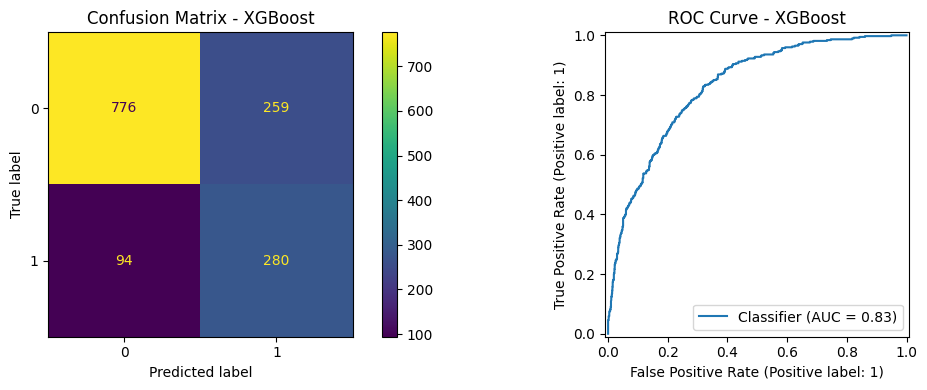

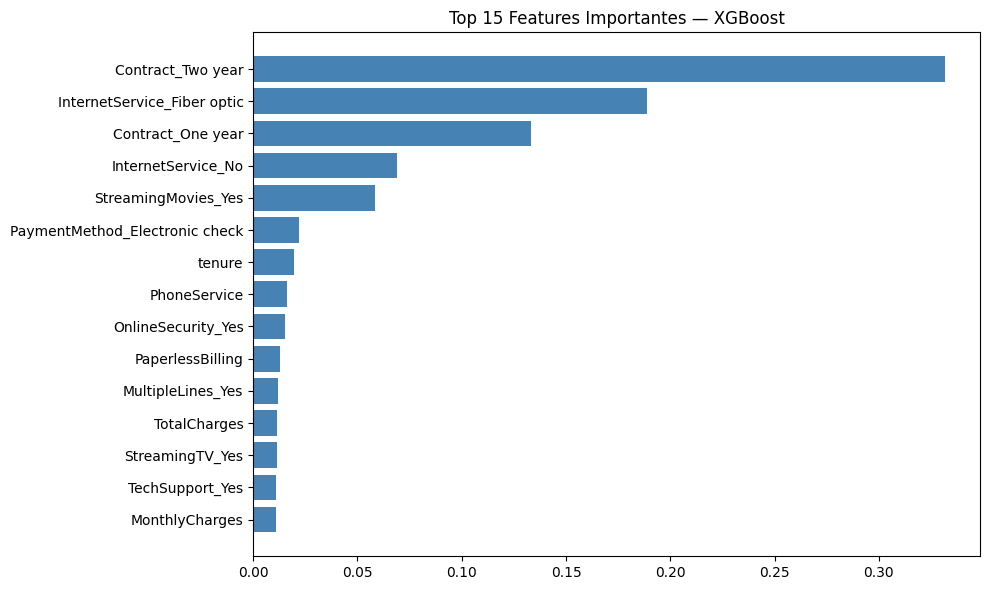

In [4]:
xgb_model = train_xgboost(X_train, y_train)
metrics_xgb = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
plot_feature_importance(xgb_model, feature_cols, "XGBoost")

0:	learn: 0.6705593	total: 135ms	remaining: 40.4s
50:	learn: 0.4613827	total: 327ms	remaining: 1.59s
100:	learn: 0.4370217	total: 468ms	remaining: 922ms
150:	learn: 0.4186729	total: 605ms	remaining: 597ms
200:	learn: 0.3993133	total: 747ms	remaining: 368ms
250:	learn: 0.3814325	total: 889ms	remaining: 174ms
299:	learn: 0.3661450	total: 1.03s	remaining: 0us
✅ CatBoost sauvegardé

  CatBoost
Accuracy  : 0.7580
Precision : 0.5295
Recall    : 0.7914
F1-Score  : 0.6345
ROC-AUC   : 0.8422


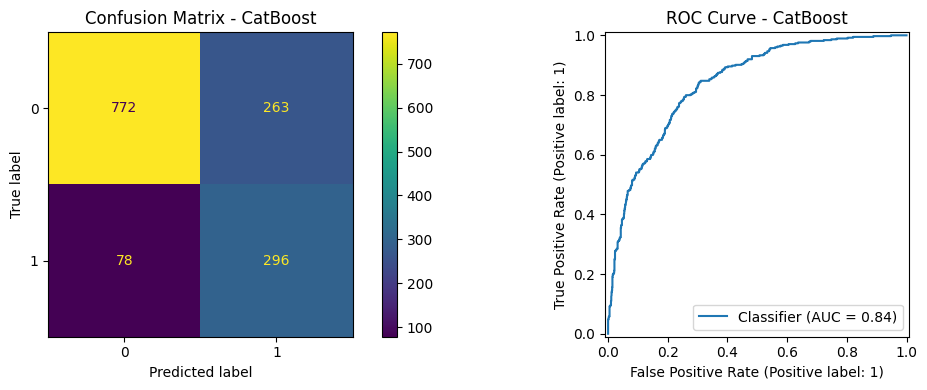

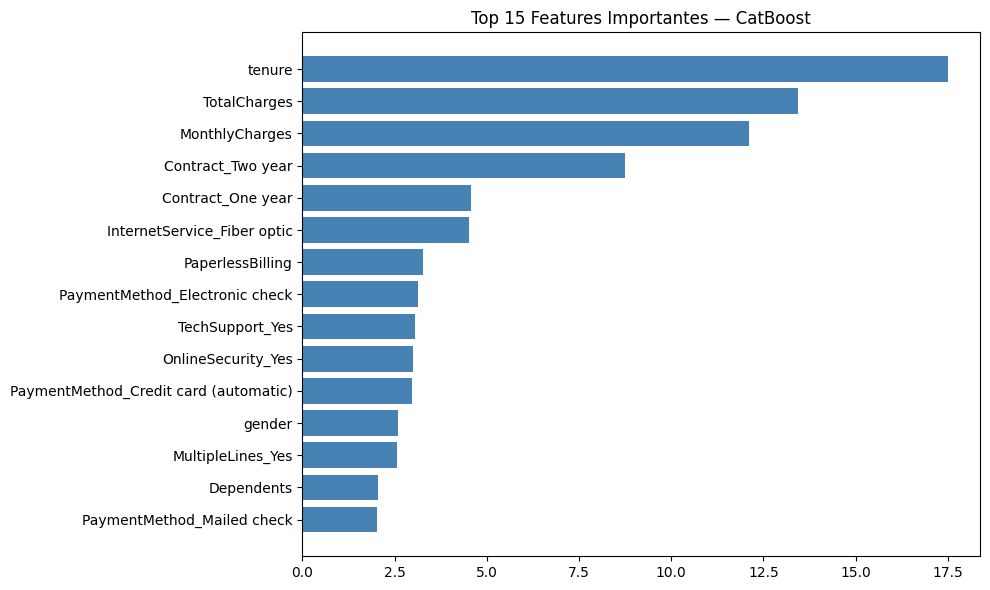

In [5]:
cat_model = train_catboost(X_train, y_train)
metrics_cat = evaluate_model(cat_model, X_test, y_test, "CatBoost")
plot_feature_importance(cat_model, feature_cols, "CatBoost")

In [6]:
import pandas as pd
comparison = pd.DataFrame({
    'XGBoost': metrics_xgb,
    'CatBoost': metrics_cat
}).T
print(comparison)

          accuracy  precision    recall        f1   roc_auc
XGBoost   0.749468   0.519481  0.748663  0.613363  0.830463
CatBoost  0.757984   0.529517  0.791444  0.634512  0.842176
